# Lab 6 - Metricas de Clasificacion Multiclase sobre Adult

En este cuadernillo aplicamos metricas de clasificacion multiclase sobre el dataset Adult para predecir la ocupacion de cada persona.

## Objetivo

Vamos a entrenar un clasificador multiclase para predecir la ocupacion (`occupation`) y evaluarlo con:

- Accuracy
- Matriz de confusion
- Precision, Recall y F1 (macro y weighted)
- Reporte de clasificacion por clase
- Curvas ROC One-vs-Rest y ROC-AUC multiclase
- Efecto del threshold (One-vs-Rest) sobre precision/recall

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    classification_report
)

## 1) Carga y preprocesamiento


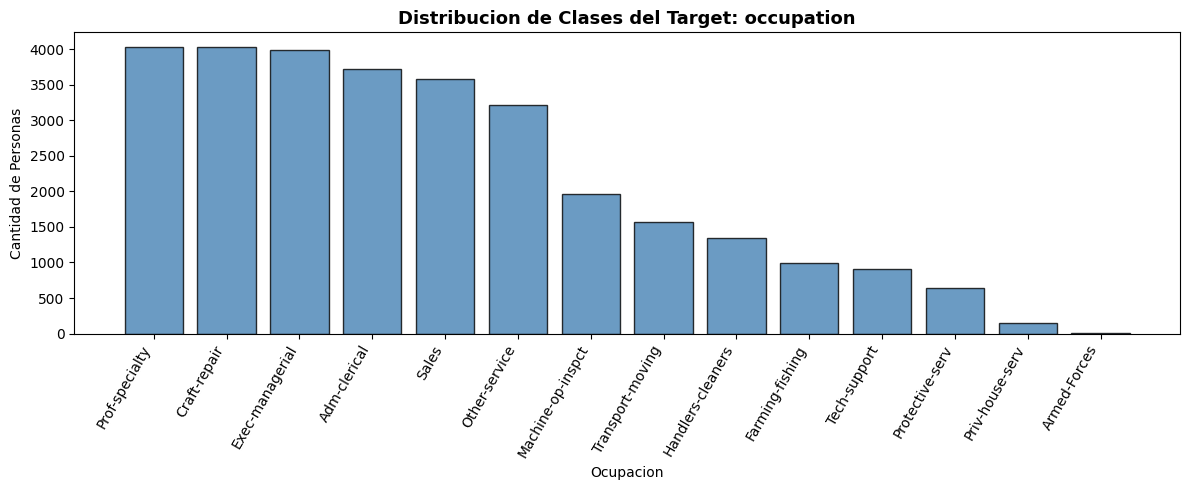

Cantidad de clases: 14
Clase mayoritaria: Prof-specialty - 4038


In [32]:
# Carga de datos para mostrar la distribucion de clases del target multiclase
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

df = pd.read_csv('adult.data', names=column_names, sep=r',\s*', engine='python', na_values='?')
df = df.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)
df_clean = df.dropna().copy()

target_counts = df_clean['occupation'].value_counts()

plt.figure(figsize=(12, 5))
plt.bar(target_counts.index, target_counts.values, color='steelblue', alpha=0.8, edgecolor='black')
plt.title('Distribucion de Clases del Target: occupation', fontsize=13, fontweight='bold')
plt.ylabel('Cantidad de Personas')
plt.xlabel('Ocupacion')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

print('Cantidad de clases:', target_counts.shape[0])
print('Clase mayoritaria:', target_counts.idxmax(), '-', int(target_counts.max()))

In [10]:
target_col = 'occupation'

X_df = df_clean.drop(columns=[target_col, 'fnlwgt'])
y_raw = df_clean[target_col].copy()

# One-hot encoding de variables categoricas
X_df = pd.get_dummies(X_df, drop_first=False)
X = X_df.values.astype(float)

le = LabelEncoder()
y = le.fit_transform(y_raw.values)
class_names = le.classes_

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

mean_train = X_train.mean(axis=0)
std_train = X_train.std(axis=0)
std_train[std_train == 0] = 1

X_train_scaled = (X_train - mean_train) / std_train
X_test_scaled = (X_test - mean_train) / std_train

print('Dataset limpio:', df_clean.shape)
print('Features finales:', X_train_scaled.shape[1])
print('Train:', X_train_scaled.shape, ' Test:', X_test_scaled.shape)
print('Cantidad de clases:', len(class_names))
print('Clases:', ', '.join(class_names))

Dataset limpio: (30162, 15)
Features finales: 91
Train: (24129, 91)  Test: (6033, 91)
Cantidad de clases: 14
Clases: Adm-clerical, Armed-Forces, Craft-repair, Exec-managerial, Farming-fishing, Handlers-cleaners, Machine-op-inspct, Other-service, Priv-house-serv, Prof-specialty, Protective-serv, Sales, Tech-support, Transport-moving


## 2) Entrenamiento del clasificador

Usamos un clasificador multiclase en **PyTorch** (regresion logistica multinomial: capa lineal + `CrossEntropyLoss`) y lo entrenamos en **CUDA** cuando esta disponible.

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32, device=device)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train, dtype=torch.long, device=device)

n_features = X_train_t.shape[1]
n_classes = len(class_names)

model = nn.Linear(n_features, n_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-4)

epochs = 300
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_t)
    loss = criterion(logits, y_train_t)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f'Epoch {epoch + 1}/{epochs} - loss: {loss.item():.4f}')

model.eval()
with torch.no_grad():
    logits_test = model(X_test_t)
    y_prob = torch.softmax(logits_test, dim=1).cpu().numpy()
    y_pred = torch.argmax(logits_test, dim=1).cpu().numpy()

y_true = y_test.copy()

print('Modelo multiclase PyTorch entrenado correctamente')

Device: cuda
Epoch 50/300 - loss: 1.9129
Epoch 100/300 - loss: 1.8753
Epoch 150/300 - loss: 1.8632
Epoch 200/300 - loss: 1.8570
Epoch 250/300 - loss: 1.8532
Epoch 300/300 - loss: 1.8508
Modelo multiclase PyTorch entrenado correctamente


## 3) Accuracy, Precision, Recall y F1

Calculamos metricas globales para el problema multiclase usando promedios `macro` y `weighted`.

In [22]:
acc_model = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)

metrics_model = {
    'Accuracy': acc_model,
    'Precision (macro)': precision_macro,
    'Recall (macro)': recall_macro,
    'F1 (macro)': f1_macro,
    'Precision (weighted)': precision_weighted,
    'Recall (weighted)': recall_weighted,
    'F1 (weighted)': f1_weighted,
}

metrics_df = pd.DataFrame([metrics_model], index=['Modelo multiclase'])
display(metrics_df.round(4))

,Accuracy,Precision (macro),Recall (macro),F1 (macro),Precision (weighted),Recall (weighted),F1 (weighted)
Modelo multiclase,0.3444,0.2784,0.236,0.223,0.3192,0.3444,0.3042


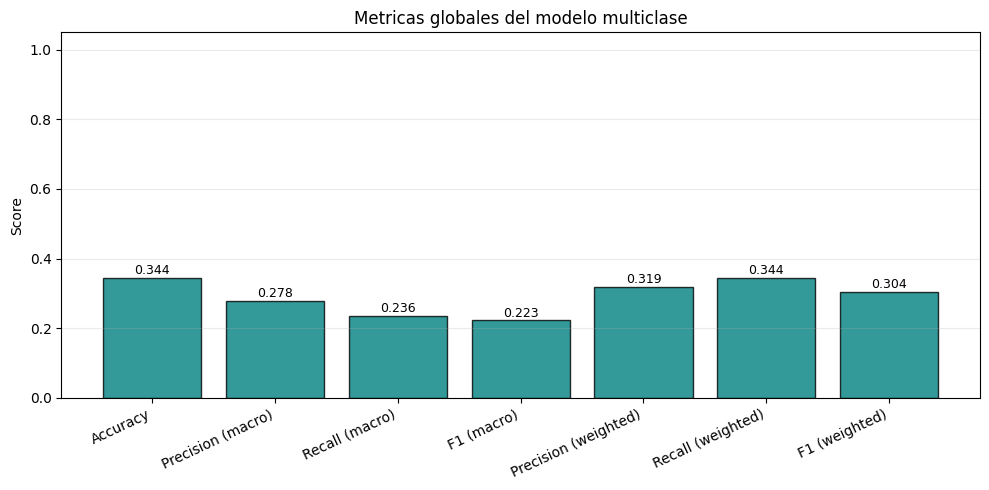

In [23]:
metric_names = list(metrics_model.keys())
metric_values = list(metrics_model.values())

plt.figure(figsize=(10, 5))
bars = plt.bar(metric_names, metric_values, color='teal', alpha=0.8, edgecolor='black')

for bar, value in zip(bars, metric_values):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.01, f'{value:.3f}', ha='center', fontsize=9)

plt.ylim(0, 1.05)
plt.ylabel('Score')
plt.title('Metricas globales del modelo multiclase')
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## 4) Matriz de confusion

La matriz de confusion multiclase muestra como se distribuyen los aciertos (diagonal) y los errores de confusion entre clases (fuera de la diagonal).

In [24]:
cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))

print('Forma de la matriz de confusion:', cm.shape)
cm_df = pd.DataFrame(
    cm,
    index=[f'Real {c}' for c in class_names],
    columns=[f'Pred {c}' for c in class_names],
)
cm_df

Forma de la matriz de confusion: (14, 14)


,Pred Adm-clerical,Pred Armed-Forces,Pred Craft-repair,Pred Exec-managerial,Pred Farming-fishing,Pred Handlers-cleaners,Pred Machine-op-inspct,Pred Other-service,Pred Priv-house-serv,Pred Prof-specialty,Pred Protective-serv,Pred Sales,Pred Tech-support,Pred Transport-moving
Real Adm-clerical,414,0,80,46,1,13,3,57,0,86,10,31,0,3
Real Armed-Forces,2,0,0,0,0,0,0,0,0,0,0,0,0,0
Real Craft-repair,32,0,525,61,15,24,19,36,0,16,23,38,2,15
Real Exec-managerial,106,0,141,277,10,0,1,15,0,197,15,33,0,4
Real Farming-fishing,4,0,83,25,28,5,8,20,0,7,2,10,0,6
Real Handlers-cleaners,21,0,123,4,0,48,7,36,0,7,6,12,1,5
Real Machine-op-inspct,46,0,215,13,2,19,30,49,2,7,3,4,0,3
Real Other-service,183,0,113,10,4,46,14,178,0,40,13,36,0,5
Real Priv-house-serv,9,0,0,0,0,1,1,16,1,1,0,0,0,0
Real Prof-specialty,82,0,49,143,1,1,1,19,0,476,9,27,0,0


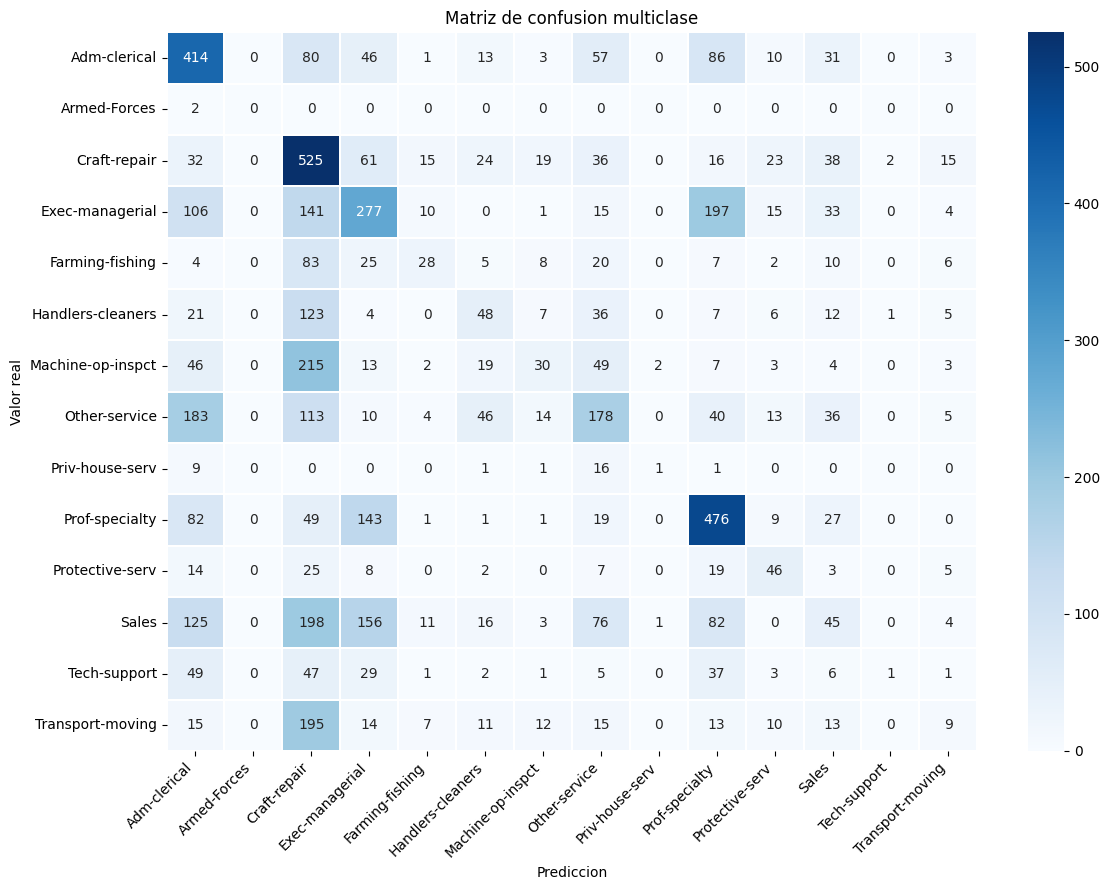

In [25]:
plt.figure(figsize=(12, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.3,
    linecolor='white',
)
plt.title('Matriz de confusion multiclase')
plt.xlabel('Prediccion')
plt.ylabel('Valor real')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

En multiclase, la **diagonal principal** representa predicciones correctas por clase.

Los valores fuera de la diagonal muestran **entre que clases se confunde** el modelo.

## 5) Reporte de clasificacion

Aca vemos el detalle por clase y las metricas globales para complementar la matriz de confusion.

In [26]:
print(f"Accuracy            : {acc_model:.4f}")
print(f"Precision (macro)   : {precision_macro:.4f}")
print(f"Recall (macro)      : {recall_macro:.4f}")
print(f"F1-score (macro)    : {f1_macro:.4f}")
print(f"Precision (weighted): {precision_weighted:.4f}")
print(f"Recall (weighted)   : {recall_weighted:.4f}")
print(f"F1-score (weighted) : {f1_weighted:.4f}")

Accuracy            : 0.3444
Precision (macro)   : 0.2784
Recall (macro)      : 0.2360
F1-score (macro)    : 0.2230
Precision (weighted): 0.3192
Recall (weighted)   : 0.3444
F1-score (weighted) : 0.3042


In [27]:
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

                   precision    recall  f1-score   support

     Adm-clerical       0.38      0.56      0.45       744
     Armed-Forces       0.00      0.00      0.00         2
     Craft-repair       0.29      0.65      0.40       806
  Exec-managerial       0.35      0.35      0.35       799
  Farming-fishing       0.35      0.14      0.20       198
Handlers-cleaners       0.26      0.18      0.21       270
Machine-op-inspct       0.30      0.08      0.12       393
    Other-service       0.34      0.28      0.30       642
  Priv-house-serv       0.25      0.03      0.06        29
   Prof-specialty       0.48      0.59      0.53       808
  Protective-serv       0.33      0.36      0.34       129
            Sales       0.17      0.06      0.09       717
     Tech-support       0.25      0.01      0.01       182
 Transport-moving       0.15      0.03      0.05       314

         accuracy                           0.34      6033
        macro avg       0.28      0.24      0.22      

## 6) Trade-off precision vs recall segun threshold (One-vs-Rest)

En multiclase, el threshold se analiza por clase. Aca tomamos una clase de referencia y la evaluamos contra el resto (One-vs-Rest).

- Threshold bajo: sube recall de la clase de interes, baja precision
- Threshold alto: sube precision, baja recall

In [28]:
focus_idx = np.bincount(y_train).argmax()
focus_class = class_names[focus_idx]

y_true_focus = (y_true == focus_idx).astype(int)
y_prob_focus = y_prob[:, focus_idx]

thresholds = np.linspace(0.1, 0.9, 17)
rows = []

for t in thresholds:
    pred_t = (y_prob_focus >= t).astype(int)
    rows.append({
        'threshold': t,
        'precision': precision_score(y_true_focus, pred_t, zero_division=0),
        'recall': recall_score(y_true_focus, pred_t, zero_division=0),
        'f1': f1_score(y_true_focus, pred_t, zero_division=0),
    })

threshold_df = pd.DataFrame(rows)
print(f'Clase analizada (OvR): {focus_class}')
threshold_df.round(4)

Clase analizada (OvR): Prof-specialty


,threshold,precision,recall,f1
0,0.10,0.3311,0.8465,0.4760
1,0.15,0.3747,0.8032,0.5110
2,0.20,0.3991,0.7512,0.5213
3,0.25,0.4494,0.6535,0.5325
4,0.30,0.5291,0.5854,0.5558
5,0.35,0.5977,0.5186,0.5553
6,0.40,0.6557,0.4691,0.5469
7,0.45,0.7137,0.4072,0.5185
8,0.50,0.7591,0.3626,0.4908
9,0.55,0.7888,0.3144,0.4496


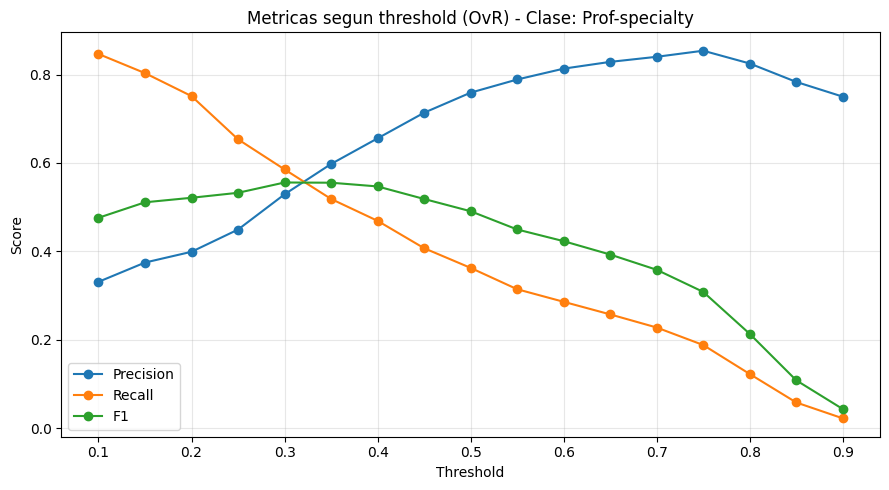

In [29]:
plt.figure(figsize=(9, 5))
plt.plot(threshold_df['threshold'], threshold_df['precision'], marker='o', label='Precision')
plt.plot(threshold_df['threshold'], threshold_df['recall'], marker='o', label='Recall')
plt.plot(threshold_df['threshold'], threshold_df['f1'], marker='o', label='F1')
plt.title(f'Metricas segun threshold (OvR) - Clase: {focus_class}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 7) Curvas ROC y ROC-AUC multiclase

En multiclase usamos enfoque One-vs-Rest (OvR): cada clase se compara contra todas las demas.

Reportamos ROC-AUC global (macro y weighted) y graficamos curvas ROC de las clases mas frecuentes.

In [30]:
y_test_bin = label_binarize(y_true, classes=np.arange(len(class_names)))

auc_macro_ovr = roc_auc_score(
    y_test_bin, y_prob, multi_class='ovr', average='macro'
 )
auc_weighted_ovr = roc_auc_score(
    y_test_bin, y_prob, multi_class='ovr', average='weighted'
 )

print(f'ROC-AUC OvR (macro)   : {auc_macro_ovr:.4f}')
print(f'ROC-AUC OvR (weighted): {auc_weighted_ovr:.4f}')

ROC-AUC OvR (macro)   : 0.8078
ROC-AUC OvR (weighted): 0.7847


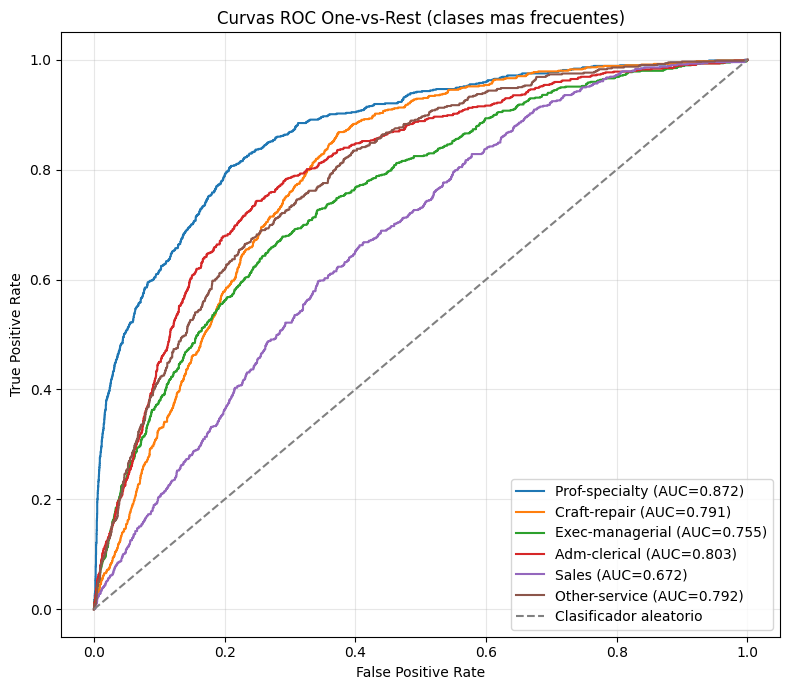

In [31]:
top_k = 6
top_classes_idx = np.bincount(y_true).argsort()[::-1][:top_k]

plt.figure(figsize=(8, 7))
for idx in top_classes_idx:
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, idx], y_prob[:, idx])
    auc_i = roc_auc_score(y_test_bin[:, idx], y_prob[:, idx])
    plt.plot(fpr_i, tpr_i, label=f"{class_names[idx]} (AUC={auc_i:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Clasificador aleatorio')
plt.title('Curvas ROC One-vs-Rest (clases mas frecuentes)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()